# Lab 6

In [2]:
### MATPLOTLIB SETUP ###
from math import sqrt, ceil, asin
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
import sys
pd.set_option('display.float_format', lambda x: '%e' % x)

## Amit's library with some utility functions for reading and processing scope data; reproduced below
sys.path.append("../../")
from lib import *

from rich.console import Console
from rich.syntax import Syntax
#Console().print(Syntax.from_path("../../lib.py", line_numbers=True, theme="monokai"))

## Jupyter magic
%matplotlib
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

Using matplotlib backend: module://matplotlib_inline.backend_inline


## Prelab

In [24]:
Vo = 10

In [25]:
## DESIRED a
alpha_want = 0.7
D_want = 0.35
a_want = (Vo/VG) * ((sqrt(alpha_want) - D_want)/(D_want))

V = Vo/a_want
Ri = R/a_want**2
M = Vo / (a_want * VG)
a_want

0.772476232593771

In [26]:
Ipk = (2/sqrt(alpha_want)) * (M+1) * V/Ri
Ipk

6.349206349206349

In [51]:
Lcrit = (1/(M+1))**2 * (R/a_want**2) * (Ts/2)
L_target = Lcrit * alpha_want
print(f"Target inductance: {L_target}") # target inductance

Target inductance: 1.9648514851485144e-05


In [123]:
Bmax = 0.3 # 200mT, given in worksheet
Ac = 59.1 / 10e5 # Found in core datasheet

L = 14e-6

max_flux = Bmax * Ac
min_turns = (L_target*Ipk) / (max_flux) 
print(f"Minimum turns: {round(min_turns, 3)}")

Minimum turns: 7.036


In [139]:
n1 = ceil(min_turns+1) # winding 1 turns
n2 = round(a_want * n1) # winding 2 turns
a = n2/n1

print(n1, n2, a)

9 7 0.7777777777777778


In [147]:
lg = 10 # user defined (mils)
lg *= 0.0254 # to mm

x1 = 7+lg
x2 = 9-lg
a1 = 2*x1 * (10.65+lg) - x1 * sqrt(x2**2-x1**2) - x2**2 * asin(x1/x2)
a2 = (d/2 + lg) ** 2 * 3.14 # area of a circle
Aeq = (2*a1 + a2)/2

Aeq /= 1000000 # to m^2
lg /= 1000 # to m

mu0 = 1.26 * 10 ** -6 # permeability of free space
Pm = mu0 * Aeq / lg

L = n1 ** 2 * Pm
L = 18.1e-6
alpha = L/Lcrit
D = sqrt(alpha) * M/(M+1)
L, alpha, D

(1.81e-05, 0.6448324514991183, 0.335925109231724)

In [138]:
irms = sqrt(D/3) * Ipk
awg22_a = 0.326
irms / awg22_a

6.7048939998562975

# LAB

In [10]:
v4, _ = import_and_clean(f't1_4v', ["Vshunt", "Vdrain"], True, 30)
v7, _ = import_and_clean(f't1_7v', ["Vshunt", "Vdrain"], True, 30)
v10, _ = import_and_clean(f't1_10v', ["Vshunt", "Vdrain"], True, 30)


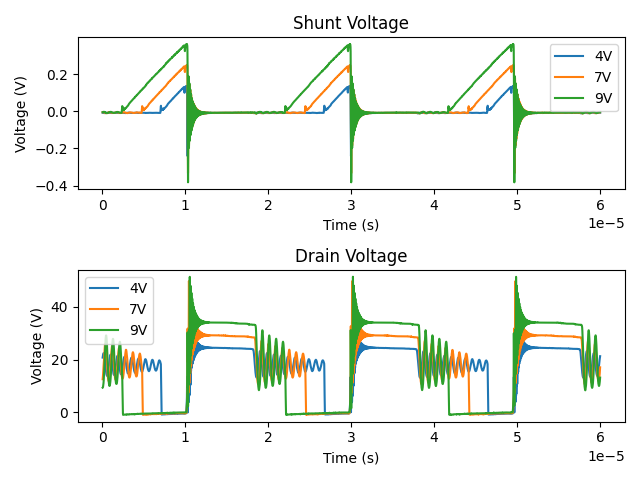

In [13]:
dfs = [v4, v7, v10]

figure, (ax1, ax2) = plt.subplots(2,1)
for df in dfs:
    df.plot(x="X", y="Vshunt", ax=ax1, title="Shunt Voltage")
    df.plot(x="X", y="Vdrain", ax=ax2, title="Drain Voltage")

ax1.legend(["4V", "7V", "9V"])
ax2.legend(["4V", "7V", "9V"])
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Voltage (V)")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Voltage (V)")
figure.tight_layout()

In [17]:
ts = [(2.71e-5, 2.93e-5), (2.49e-5, 2.93e-5), (2.25e-5, 2.93e-5)]
Vs = [4.01, 7.01, 10.06]
Ls = []

for df, t, V in zip(dfs, ts, Vs):
    Ls.append(L := calc_inductance(df, *t, VG)) 
    print(f"Magnetizing inductance at output voltage of {V}V: {round(L * 10e5, 3)} uH")
print(f"Mean Inductance: {round((Lmean := np.mean(Ls)) * 10e5, 3)} uH")

Magnetizing inductance at output voltage of 4.01V: 18.206 uH
Magnetizing inductance at output voltage of 7.01V: 18.474 uH
Magnetizing inductance at output voltage of 10.06V: 18.789 uH
Mean Inductance: 18.49 uH
